In [1]:
import pathlib
import random
import numpy as np
from qiskit import QuantumCircuit, transpile
import seaborn as sns
from qiskit.transpiler.passes import ApplyLayout

from contrib.common import read_json, read_mapping
from contrib.initial_mapping import get_initial_mapping, InitialMappingStrategy
from hamap.initial_mapping import initial_mapping_from_sabre
from hamap.mapping import ha_mapping
from hamap import IBMQHardwareArchitecture
from contrib.random_graphs import create_coupling_graph
from qiskit.quantum_info import DensityMatrix, Statevector
from typing import Union
from qiskit.transpiler.passmanager import PassManager

import networkx as nx
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Instruction, CircuitInstruction
from qiskit.quantum_info import Statevector
from qiskit.transpiler import CouplingMap, TranspileLayout


/tmp/ipykernel_26927/1977602396.py:4: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit, transpile


In [6]:
qc_in = QuantumCircuit.from_qasm_file('./input.qasm')
qc_out = QuantumCircuit.from_qasm_file('./output.qasm')
mapping = read_mapping('./initial_mapping.json')

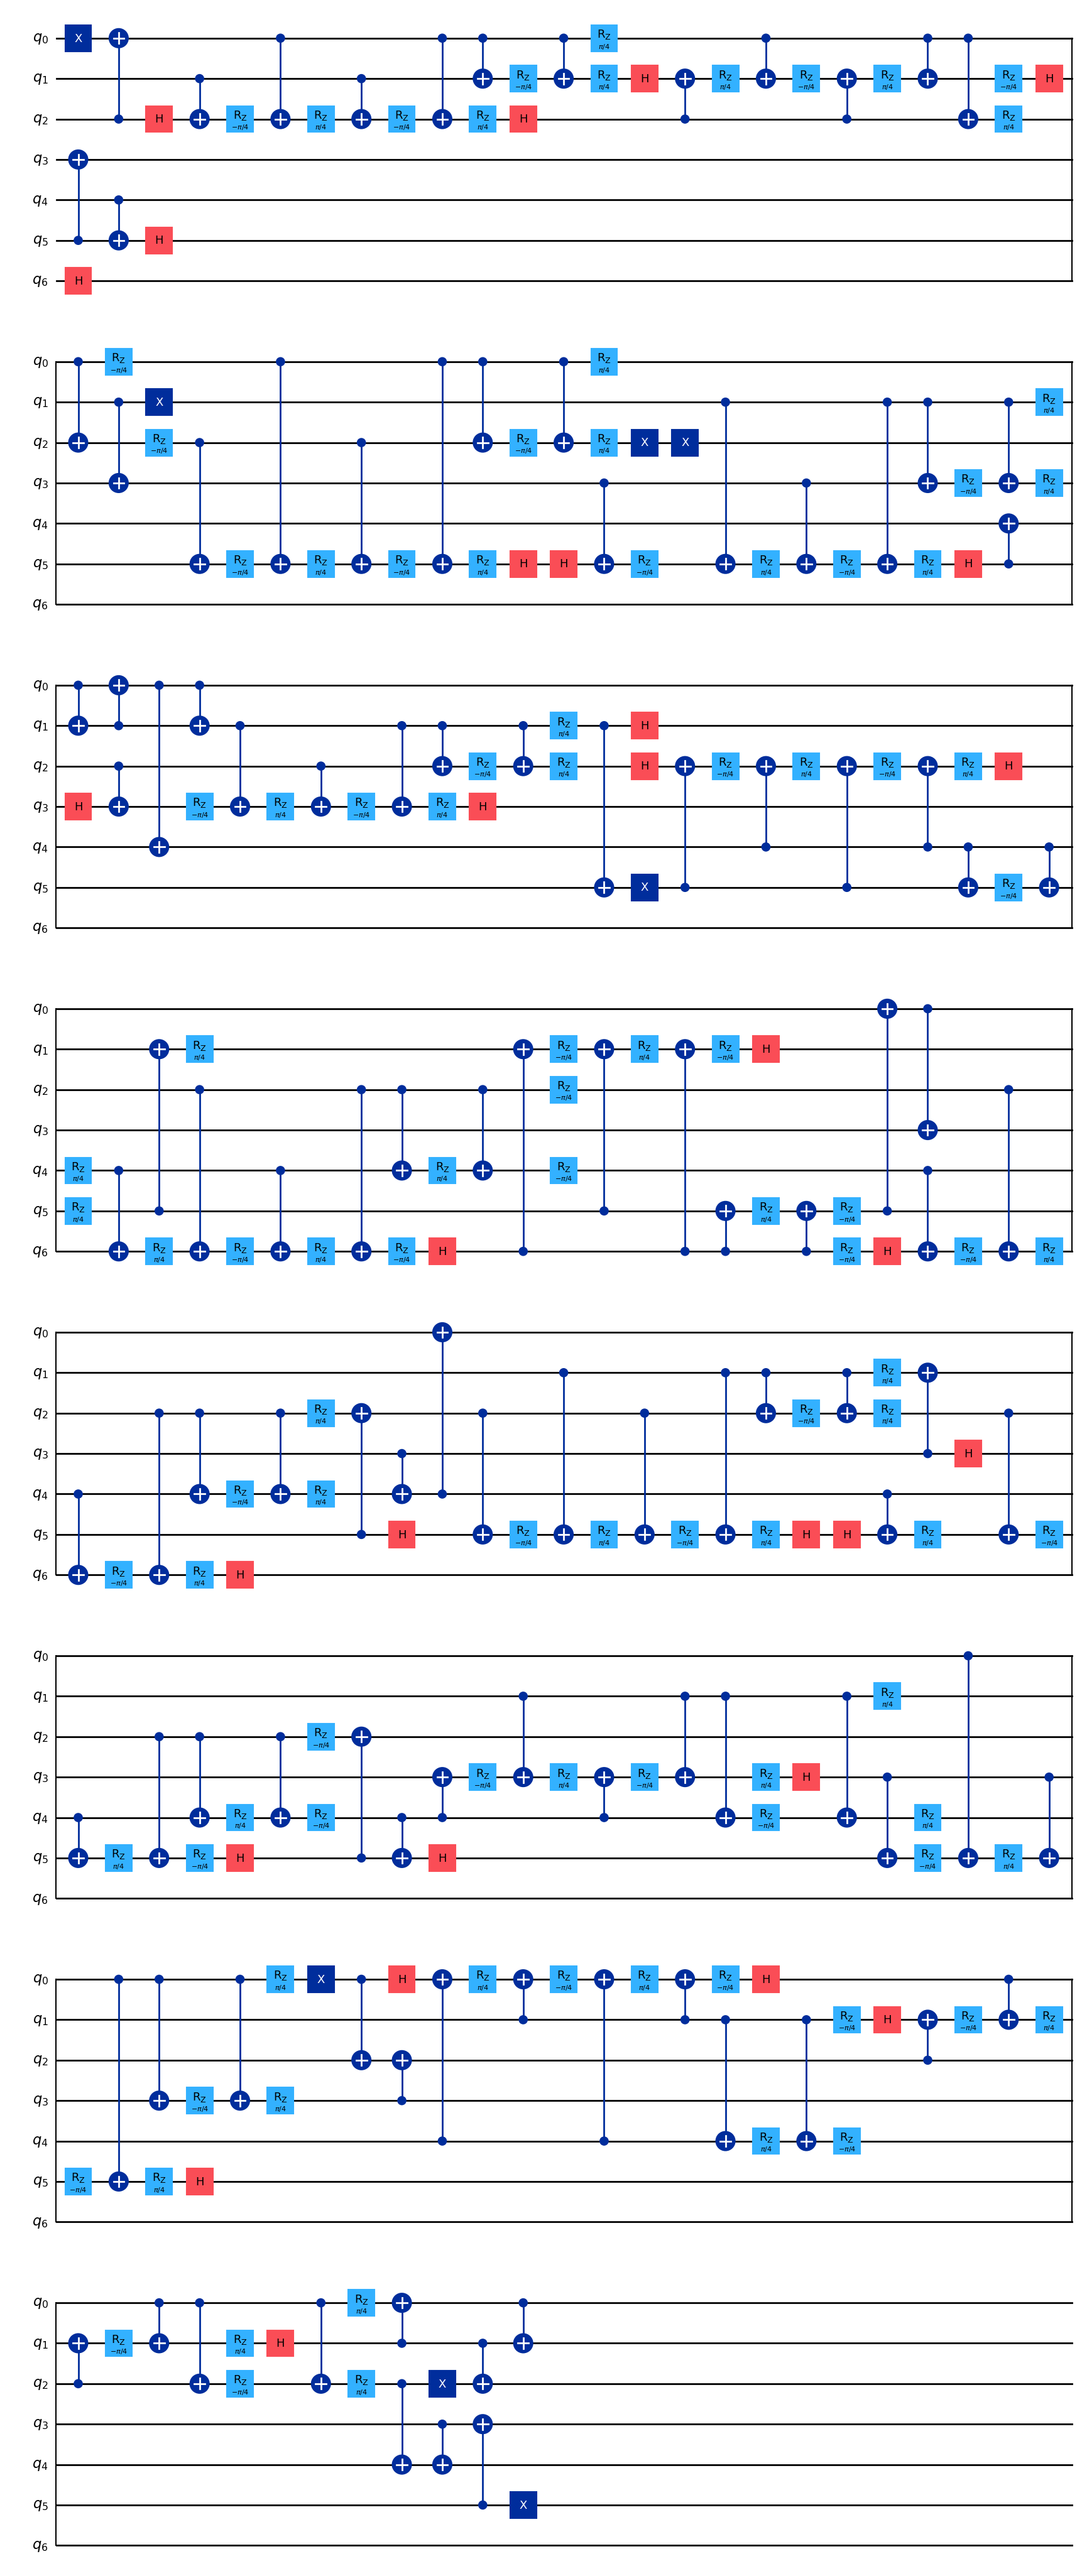

In [8]:
qc_in.draw('mpl')

In [10]:
from contrib.verify_circuit import check_equivalence

check_equivalence(qc_in, qc_out, initial_mapping=mapping)

False

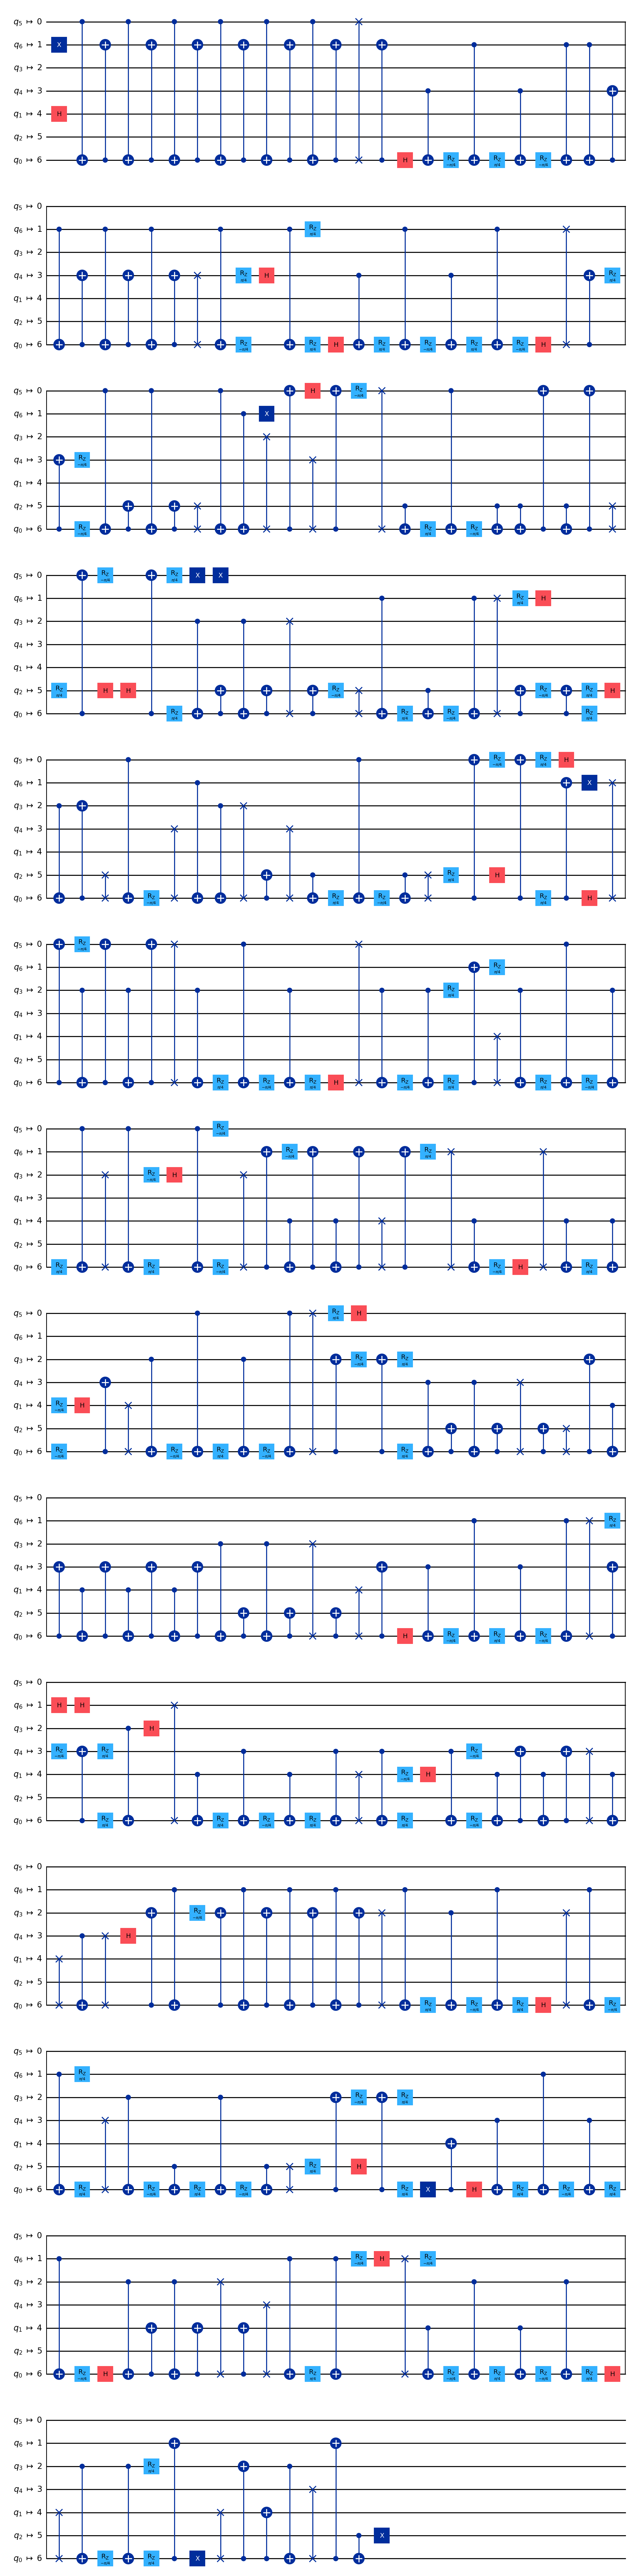

In [24]:
from hamap.mapping import apply_layout


apply_layout(qc_out, mapping).draw('mpl')

In [25]:
mapping

{0: 6, 1: 4, 2: 5, 3: 2, 4: 3, 5: 0, 6: 1}

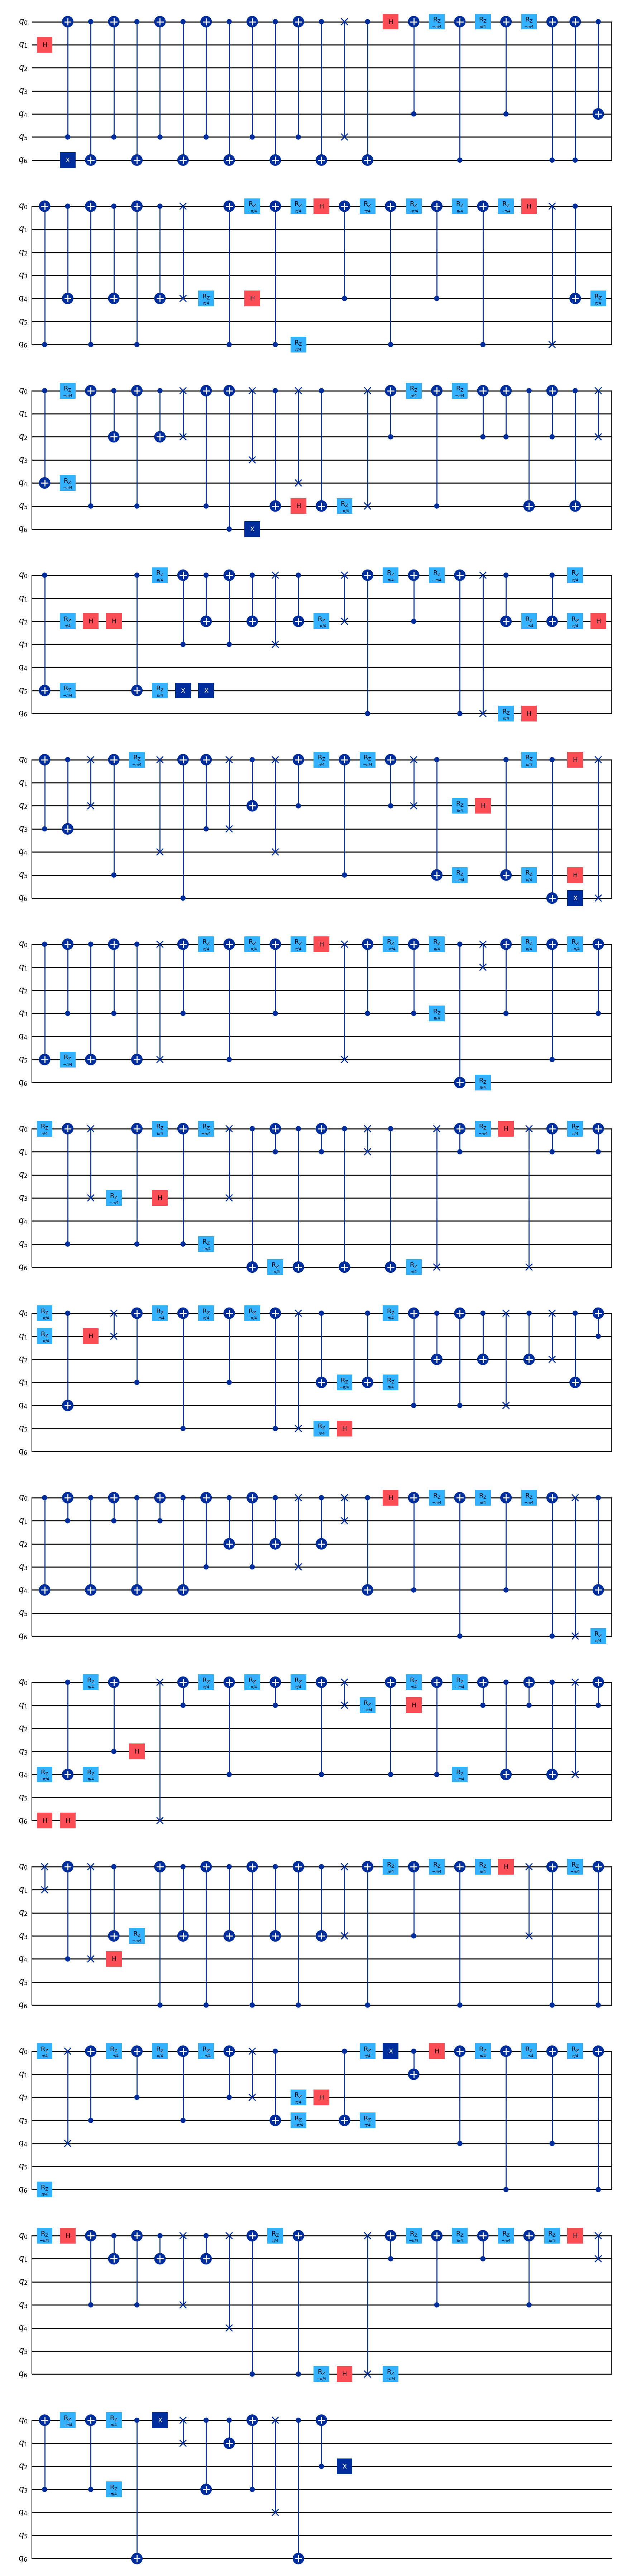

In [11]:
qc_out.draw('mpl')

In [12]:
mapping

{0: 6, 1: 4, 2: 5, 3: 2, 4: 3, 5: 0, 6: 1}

In [21]:
diff = np.abs(Statevector(qc_out).data) - np.abs(Statevector(qc_in).data)

In [22]:
diff[abs(diff) < 1e-10] = 0

In [23]:
diff

array([-1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.70710678,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.70710678,  0.        ,  0.        ,  0.  